In [13]:
# import the needed files
import pystac_client
import stackstac
import matplotlib.pyplot as plt

In [14]:
# searches metadata and loads requested info only
stac_url = "https://earth-search.aws.element84.com/v1"
client = pystac_client.Client.open(stac_url)

# define the UCF bounding box [min_lon, min_lat, max_lon, max_lat]
ucf_bbox = [-81.207624, 28.591923, -81.186510, 28.611922]
date_range = "2023-01-01/2023-12-31"

# asks the remote database what info exists
search = client.search(
    #specifying sentinel 2-12a
    collections=["sentinel-2-l2a"],
    bbox=ucf_bbox,
    datetime=date_range,
    query={"eo:cloud_cover": {"lt": 20}}
)
items = search.item_collection()
print(f"Found {len(items)} scenes!")

Found 22 scenes!


In [15]:
# build the stack
stack = stackstac.stack(items, assets=["red", "nir"], bounds_latlon=ucf_bbox, epsg=4326)

# isolate the correct info
red = stack.sel(band="red").astype(float)
nir = stack.sel(band="nir").astype(float)

# calculating nvdi
ndvi = (nir - red) / (nir + red)

# filter out the infinite/divide-by-zero values
ndvi = ndvi.where((ndvi >= -1) & (ndvi <= 1))

# average nvdi for each specific date
mean_ndvi = ndvi.mean(dim=["x", "y"], skipna=True) 

# run math and print check
mean_ndvi_computed = mean_ndvi.compute()
print("NDVI math completed")

C:\Users\Maia Keefe\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\dask\_task_spec.py:768: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)


NDVI math completed


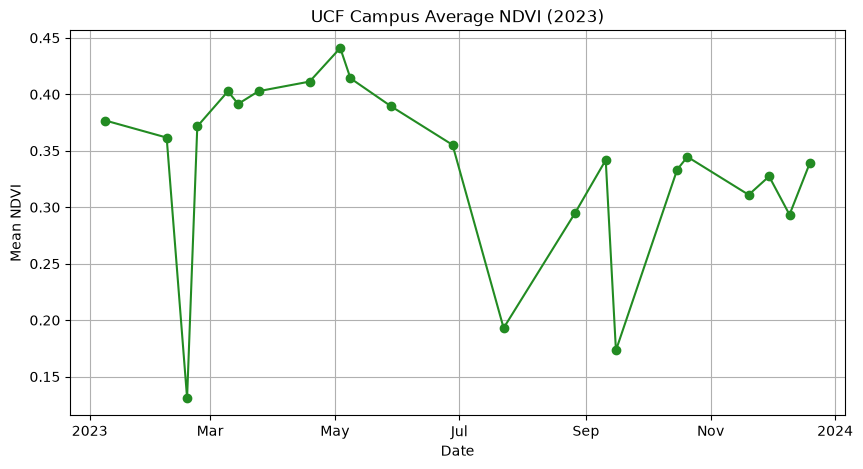

In [16]:
# create and plot graph
plt.figure(figsize=(10, 5))
mean_ndvi_computed.plot.line(marker='o', color='forestgreen')
plt.title("UCF Campus Average NDVI (2023)")
plt.ylabel("Mean NDVI")
plt.xlabel("Date")
plt.grid(True)
plt.show()